# 🔬 Computational Pathology (CPath) WSI Preprocessing Pipeline
## Quy trình tiền xử lý, Kiểm định chất lượng (QC) & Trích xuất đặc trưng tiêu bản Whole Slide Image (.svs)

Notebook này được thiết kế theo tiêu chuẩn từng bước (Step-by-Step Educational & Production Pipeline), minh họa chi tiết từng kỹ thuật toán học, thị giác máy tính và quang phổ học bệnh lý được sử dụng để lọc sạch $100\%$ nền trắng, khử nhiễu vết mực, phân tích mật độ tế bào và cắt patch có quy luật.

> **Lưu ý lưu trữ & Tải dữ liệu**: Tất cả dữ liệu đầu vào (`.svs`), ảnh patch đầu ra (`.jpg`), file manifest (`.csv`) và file nén (`.zip`) đều được **lưu trực tiếp tại thư mục dự án hiện tại (ổ đĩa làm việc của bạn)**. Hệ thống được tích hợp **cơ chế kiểm tra trùng lặp thông minh (Smart Caching)**: nếu file dữ liệu đã được tải hoặc patch đã được cắt, hệ thống sẽ **tự động bỏ qua không tải lại / không cắt lại** để tiết kiệm tối đa thời gian.

### 📌 BẢNG TỔNG HỢP CÁC KỸ THUẬT SỬ DỤNG TRONG NOTEBOOK

| Cell | Tên bước | Kỹ thuật & Thuật toán áp dụng | Mục đích & Ý nghĩa kỹ thuật |
| :--- | :--- | :--- | :--- |
| **Cell 1** | Môi trường | `Cross-Platform DLL Hooking (openslide-bin)` | Tự động liên kết thư viện C của OpenSlide trên cả Windows lẫn Linux/Kaggle. |
| **Cell 2** | Tải & Khảo sát | `Smart Existence Check & Local Ingestion` | Kiểm tra dữ liệu đã tải chưa; nếu có sẵn thì tự động bỏ qua không tải lại. |
| **Cell 3** | Khảo sát SVS | `Pyramid Multi-Resolution Inspection` | Đọc cấu trúc kim tự tháp đa tầng (Levels 0, 1, 2...), trích xuất độ phóng đại $20\times/40\times$. |
| **Cell 4** | Phân đoạn mô | `HSV Decomposition + Otsu's Thresholding + Morphology` | • **HSV**: Bắt màu nhuộm H&E qua kênh Saturation.<br>• **Otsu**: Tự động tìm ngưỡng tối ưu hóa phương sai giữa 2 lớp.<br>• **Morphology**: Phép đóng/mở hình học để lấp lỗ hổng tế bào và khử bụi kính. |
| **Cell 5** | Trích xuất đặc trưng | `Tissue-Guided Coordinate Sampling & H&E Deconvolution` | Tự động tìm vị trí có mô thật để trích xuất patch mẫu, đo độ nét Laplace và nồng độ H&E. |
| **Cell 6** | Thực thi song song | `GIL-Free ThreadPoolExecutor & Smart Resume` | Chạy đa luồng song song không bị crash ProcessPool trên Windows, lọc theo ngưỡng mô $\ge 50\%$. |
| **Cell 7** | Báo cáo thống kê | `Pathology Profiling Dashboard (6 Charts)` | Phân tích phân phối diện tích mô, phổ quang học H&E, tương quan độ nét và mật độ u. |
| **Cell 8** | Bản đồ không gian | `2D Spatial Heatmap Reconstruction` | Tái tạo toàn cảnh tiêu bản thành bản đồ phân bố mật độ tế bào (Cellularity) và chất lượng quang học. |
| **Cell 9** | Đóng gói | `Manifest CSV Export & Streamlined ZIP Archiving` | Xuất bảng metadata cho từng patch và nén tập dữ liệu sạch ngay trong thư mục dự án. |

---

## 🛠️ Cell 1: Khởi tạo môi trường & Tự động nạp C-Library OpenSlide (Windows & Linux)

In [30]:
# [CELL 1] CÀI ĐẶT & LIÊN KẾT THƯ VIỆN ĐA NỀN TẢNG
# Kỹ thuật: Cross-Platform DLL Hooking & Dynamic Binary Binding

import sys
import os
import subprocess

print(f"[+] Hệ điều hành hiện tại: {sys.platform.upper()}")
print(f"[+] Phiên bản Python: {sys.version.split()[0]}")

# 1. Danh sách ánh xạ module Python và tên package pip tương ứng
module_package_map = {
    "cv2": "opencv-python-headless",
    "PIL": "Pillow",
    "openslide_bin": "openslide-bin",
    "kagglehub": "kagglehub",
    "requests": "requests",
    "tqdm": "tqdm",
    "seaborn": "seaborn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib"
}

for mod, pkg in module_package_map.items():
    try:
        __import__(mod)
    except ImportError:
        if mod == "openslide_bin" and not sys.platform.startswith('win'):
            continue
        print(f"[i] Đang cài đặt thư viện còn thiếu: {pkg}...")
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", pkg], check=False)
        except Exception:
            pass

# 2. Nếu chạy trên Windows: Nạp DLL qua openslide-bin
if sys.platform.startswith('win'):
    try:
        import openslide_bin
        print("[✓ Windows] Đã nạp OpenSlide C-DLL thành công qua `openslide-bin`.")
    except ImportError:
        pass

# 3. Nếu chạy trên Linux/Kaggle: Cài đặt libopenslide0 hệ thống
elif sys.platform.startswith('linux'):
    print("[i Linux/Kaggle] Kiểm tra thư viện C libopenslide-dev...")
    os.system("apt-get update -qq && apt-get install -y -qq libopenslide0 libopenslide-dev > /dev/null 2>&1")

# 4. Import các thư viện xử lý ảnh chính và in bảng thông số
try:
    import openslide
    import cv2
    import PIL
    from PIL import Image
    import numpy as np
    import pandas as pd
    import matplotlib
    import seaborn as sns
    
    print("\n" + "="*60)
    print(f"[✓] KẾT NỐI THÀNH CÔNG TẤT CẢ CÁC THƯ VIỆN CHUYÊN DỤNG:")
    print(f"  • OpenSlide Version   : {openslide.__version__}")
    print(f"  • OpenCV Version      : {cv2.__version__}")
    print(f"  • PIL (Pillow) Version: {PIL.__version__}")
    print(f"  • NumPy Version       : {np.__version__}")
    print(f"  • Pandas Version      : {pd.__version__}")
    print("="*60)
except Exception as e:
    print(f"[LỖI] Không thể import thư viện: {e}")

[+] Hệ điều hành hiện tại: WIN32
[+] Phiên bản Python: 3.11.7
[✓ Windows] Đã nạp OpenSlide C-DLL thành công qua `openslide-bin`.

[✓] KẾT NỐI THÀNH CÔNG TẤT CẢ CÁC THƯ VIỆN CHUYÊN DỤNG:
  • OpenSlide Version   : 1.4.6
  • OpenCV Version      : 4.13.0
  • PIL (Pillow) Version: 11.3.0
  • NumPy Version       : 2.4.2
  • Pandas Version      : 2.3.3


## ⚙️ Cell 2: Kiểm tra Dữ liệu đã có (Không tải lại nếu đã tồn tại) & Cấu hình Tham số

In [31]:
# [CELL 2] KIỂM TRA DỮ LIỆU ĐÃ TẢI & CẤU HÌNH ĐƯỜNG DẪN DỰ ÁN
# Kỹ thuật: Smart Data Existence Verification & Redundancy Prevention

import glob
import shutil
import requests

# 1. Thiết lập thư mục dự án
PROJECT_ROOT = os.getcwd()
os.environ["KAGGLEHUB_CACHE"] = os.path.join(PROJECT_ROOT, ".kagglehub_cache")

if os.path.exists("/kaggle/input/cancer-multi-omics-and-imaging-data"):
    INPUT_DIR = "/kaggle/input/cancer-multi-omics-and-imaging-data"
    OUTPUT_DIR = "/kaggle/working/processed_patches"
else:
    INPUT_DIR = os.path.join(PROJECT_ROOT, "cancer-multi-omics-and-imaging-data")
    OUTPUT_DIR = os.path.join(PROJECT_ROOT, "processed_patches")

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. BƯỚC KIỂM TRA THÔNG MINH: Đã có file .svs hợp lệ trong thư mục chưa?
existing_svs = sorted(glob.glob(os.path.join(INPUT_DIR, "**", "*.svs"), recursive=True))
valid_svs = [f for f in existing_svs if os.path.getsize(f) > 1024*1024]

if len(valid_svs) > 0:
    print("="*75)
    print(f"[✓] ĐÃ TÌM THẤY {len(valid_svs)} FILE .SVS CÓ SẴN TRONG DỰ ÁN:")
    total_size_mb = sum(os.path.getsize(f) for f in valid_svs) / (1024 * 1024)
    for i, f in enumerate(valid_svs, 1):
        sz = os.path.getsize(f) / (1024 * 1024)
        print(f"  [{i}] {os.path.basename(f)} ({sz:.2f} MB) -> {f}")
    print(f"  -> Tổng dung lượng dữ liệu: {total_size_mb:.2f} MB")
    print("[*] HỆ THỐNG: BỎ QUA BƯỚC TẢI LẠI (Không tải trùng lặp)!")
    print("="*75)
    svs_files = valid_svs

else:
    print(f"[!] Chưa tìm thấy file .svs hợp lệ trong: {INPUT_DIR}")
    print(f"[+] Đang tiến hành tải dữ liệu lần đầu về thư mục dự án...")
    
    # Cách 1: Thử tải qua KaggleHub
    try:
        import kagglehub
        print("  -> Kết nối KaggleHub tải dataset: ammarshafiq/cancer-multi-omics-and-imaging-data...")
        cache_path = kagglehub.dataset_download("ammarshafiq/cancer-multi-omics-and-imaging-data")
        cached_svs = glob.glob(os.path.join(cache_path, "**", "*.svs"), recursive=True)
        for src_f in cached_svs:
            dest_f = os.path.join(INPUT_DIR, os.path.basename(src_f))
            if not os.path.exists(dest_f):
                shutil.copy2(src_f, dest_f)
        print(f"  [✓] Đã đồng bộ {len(cached_svs)} file SVS về: {INPUT_DIR}")
    except Exception as e:
        print(f"  [i] Tải qua KaggleHub chưa được ({e}). Tải trực tiếp các slide tiêu bản chuẩn...")
    
    # Cách 2: Tải trực tiếp các slide tiêu bản chuẩn từ server mở
    demo_slides = [
        ("https://openslide.cs.cmu.edu/download/openslide-testdata/Aperio/CMU-1.svs", "TCGA-SAMPLE-CMU-1.svs"),
        ("https://openslide.cs.cmu.edu/download/openslide-testdata/Aperio/JP2K-33003-1.svs", "TCGA-SAMPLE-JP2K-1.svs")
    ]
    for url, fname in demo_slides:
        target_path = os.path.join(INPUT_DIR, fname)
        if os.path.exists(target_path) and os.path.getsize(target_path) > 1024*1024:
            print(f"  [✓] File {fname} đã tồn tại ({os.path.getsize(target_path)/(1024*1024):.1f} MB), bỏ qua tải lại.")
            continue
            
        print(f"  -> Đang tải tiêu bản SVS vào thư mục dự án: {fname}...")
        resp = requests.get(url, stream=True)
        if resp.status_code == 200:
            with open(target_path, "wb") as f:
                for chunk in resp.iter_content(chunk_size=1024*1024):
                    f.write(chunk)
            size_mb = os.path.getsize(target_path) / (1024*1024)
            print(f"    [✓] Đã lưu thành công: {fname} ({size_mb:.1f} MB)")
            
    svs_files = sorted(glob.glob(os.path.join(INPUT_DIR, "**", "*.svs"), recursive=True))

# 3. Tham số cấu hình chuẩn y học
PATCH_SIZE = 512           # Kích thước ảnh vuông: 512x512 pixels
TARGET_MAG = 20            # Độ phóng đại mục tiêu: 20x
TISSUE_THRESHOLD = 0.50    # Ngưỡng diện tích mô: >= 50% diện tích patch là mô thật
MIN_BLUR_SCORE = 60.0      # Ngưỡng độ nét: >= 60.0
MAX_INK_RATIO = 0.05       # Ngưỡng vết mực tối đa: <= 5%
JPEG_QUALITY = 85          # Chất lượng nén JPG (85%)
DOWNSAMPLE_MASK = 32       # Tỷ lệ thu nhỏ thumbnail: 32x
NUM_WORKERS = 4            # Số luồng CPU song song

print(f"\n[✓] Tổng số slide sẵn sàng xử lý: {len(svs_files)} slides.")

[✓] ĐÃ TÌM THẤY 172 FILE .SVS CÓ SẴN TRONG DỰ ÁN:
  [1] TCGA-4P-AA8J.svs (264.70 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-4P-AA8J.svs
  [2] TCGA-BA-4074.svs (59.23 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-4074.svs
  [3] TCGA-BA-4077.svs (75.59 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-4077.svs
  [4] TCGA-BA-5153.svs (58.37 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-5153.svs
  [5] TCGA-BA-5556.svs (38.64 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-5556.svs
  [6] TCGA-BA-5557.svs (35.84 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-5557.svs
  [7] TCGA-BA-6872.svs (80.50 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-6872.svs
  [8] TCGA-BA-6873.svs (32.38 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-6873.svs
  [9] TCGA-BA-7269.svs (73.02 MB) -> d:\nb-w-output\cancer-multi-omics-and-imaging-data\TCGA-BA-7269.svs
  [1

## 🔍 Cell 3: Khảo sát cấu trúc Kim tự tháp đa tầng (Multi-Resolution Pyramid) của 1 Slide mẫu

=== THÔNG SỐ CHI TIẾT CỦA TIÊU BẢN: TCGA-4P-AA8J ===
  • Nhà sản xuất máy quét (Vendor) : aperio
  • Độ phóng đại gốc (Magnification): 40.0x
  • Kích thước Level 0 (Gốc)        : 105,576 x 28,094 pixels (~2966.1 Megapixels)
  • Kích thước mỗi pixel (MPP_X)    : 0.2525 µm/pixel
  • Số tầng kim tự tháp (Levels)   : 4 levels

--- BẢNG CÁC TẦNG PHÂN GIẢI (PYRAMID LEVELS) ---
  Level 0: Kích thước = 105,576 x 28,094 | Tỷ lệ thu nhỏ =   1.00x
  Level 1: Kích thước = 26,394 x  7,023 | Tỷ lệ thu nhỏ =   4.00x
  Level 2: Kích thước =  6,598 x  1,755 | Tỷ lệ thu nhỏ =  16.00x
  Level 3: Kích thước =  3,299 x    877 | Tỷ lệ thu nhỏ =  32.02x
--------------------------------------------------



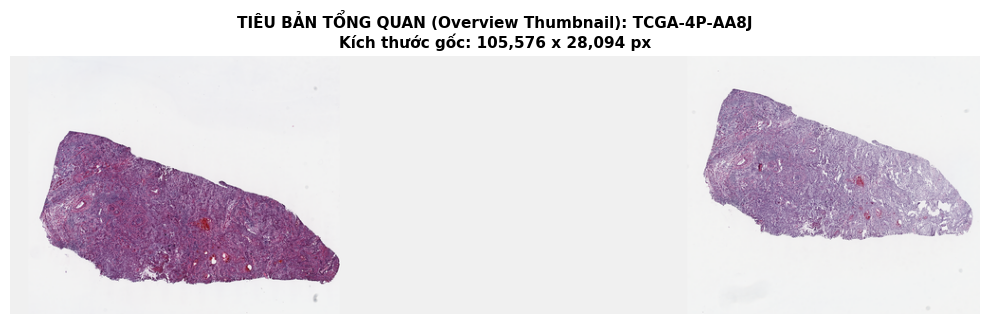

In [32]:
# [CELL 3] KHẢO SÁT CẤU TRÚC KIM TỰ THÁP WSI
# Kỹ thuật: Whole Slide Multi-Resolution Pyramid Decoding & Header Metadata Parsing

import matplotlib.pyplot as plt

def get_slide_mag(slide_obj):
    """Hàm trích xuất an toàn độ phóng đại từ header WSI (Aperio, Hamamatsu, Leica, v.v.)"""
    for k in ["openslide.apparent-magnification", "aperio.AppMag", "hamamatsu.SourceLens"]:
        if k in slide_obj.properties:
            try:
                return float(slide_obj.properties[k])
            except ValueError:
                pass
    return 40.0

if len(svs_files) > 0:
    sample_path = svs_files[0]
    slide = openslide.OpenSlide(sample_path)
    slide_name = os.path.splitext(os.path.basename(sample_path))[0]
    
    # 1. Trích xuất metadata an toàn từ Header của file SVS
    w_0, h_0 = slide.dimensions
    num_levels = slide.level_count
    app_mag = get_slide_mag(slide)
    vendor = slide.properties.get("openslide.vendor", "Chưa rõ")
    mpp_x = slide.properties.get("openslide.mpp-x", "N/A")
    
    print(f"=== THÔNG SỐ CHI TIẾT CỦA TIÊU BẢN: {slide_name} ===")
    print(f"  • Nhà sản xuất máy quét (Vendor) : {vendor}")
    print(f"  • Độ phóng đại gốc (Magnification): {app_mag}x")
    print(f"  • Kích thước Level 0 (Gốc)        : {w_0:,} x {h_0:,} pixels (~{w_0*h_0/1e6:.1f} Megapixels)")
    print(f"  • Kích thước mỗi pixel (MPP_X)    : {mpp_x} µm/pixel")
    print(f"  • Số tầng kim tự tháp (Levels)   : {num_levels} levels\n")
    
    print("--- BẢNG CÁC TẦNG PHÂN GIẢI (PYRAMID LEVELS) ---")
    for lvl in range(num_levels):
        dim = slide.level_dimensions[lvl]
        down = slide.level_downsamples[lvl]
        print(f"  Level {lvl}: Kích thước = {dim[0]:>6,} x {dim[1]:>6,} | Tỷ lệ thu nhỏ = {down:>6.2f}x")
    print("--------------------------------------------------\n")
    
    # 2. Trích xuất Thumbnail hiển thị tổng quan
    thumb_dim = (1024, int(1024 * (h_0 / w_0)))
    thumbnail = slide.get_thumbnail(thumb_dim).convert("RGB")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(thumbnail)
    plt.title(f"TIÊU BẢN TỔNG QUAN (Overview Thumbnail): {slide_name}\nKích thước gốc: {w_0:,} x {h_0:,} px", fontsize=11, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    slide.close()
else:
    print("[!] Bỏ qua cell này vì chưa tìm thấy file SVS.")

## 🧪 Cell 4: Phân tích từng bước Phân đoạn mô (HSV + Otsu Thresholding + Morphology)

=== KẾT QUẢ TÍNH TOÁN PHÂN ĐOẠN MÔ CHO SLIDE: TCGA-4P-AA8J.svs ===
  • Ngưỡng Otsu tự động tìm được trên kênh Saturation : T* = 51.0 / 255
  • Tổng số pixel trên mask thumbnail                  : 2,893,223 pixels
  • Số pixel nhận diện là MÔ THỰC                      : 584,551 pixels (20.20%)
  • Số pixel nhận diện là NỀN TRẮNG/KÍNH               : 2,308,672 pixels (79.80%)


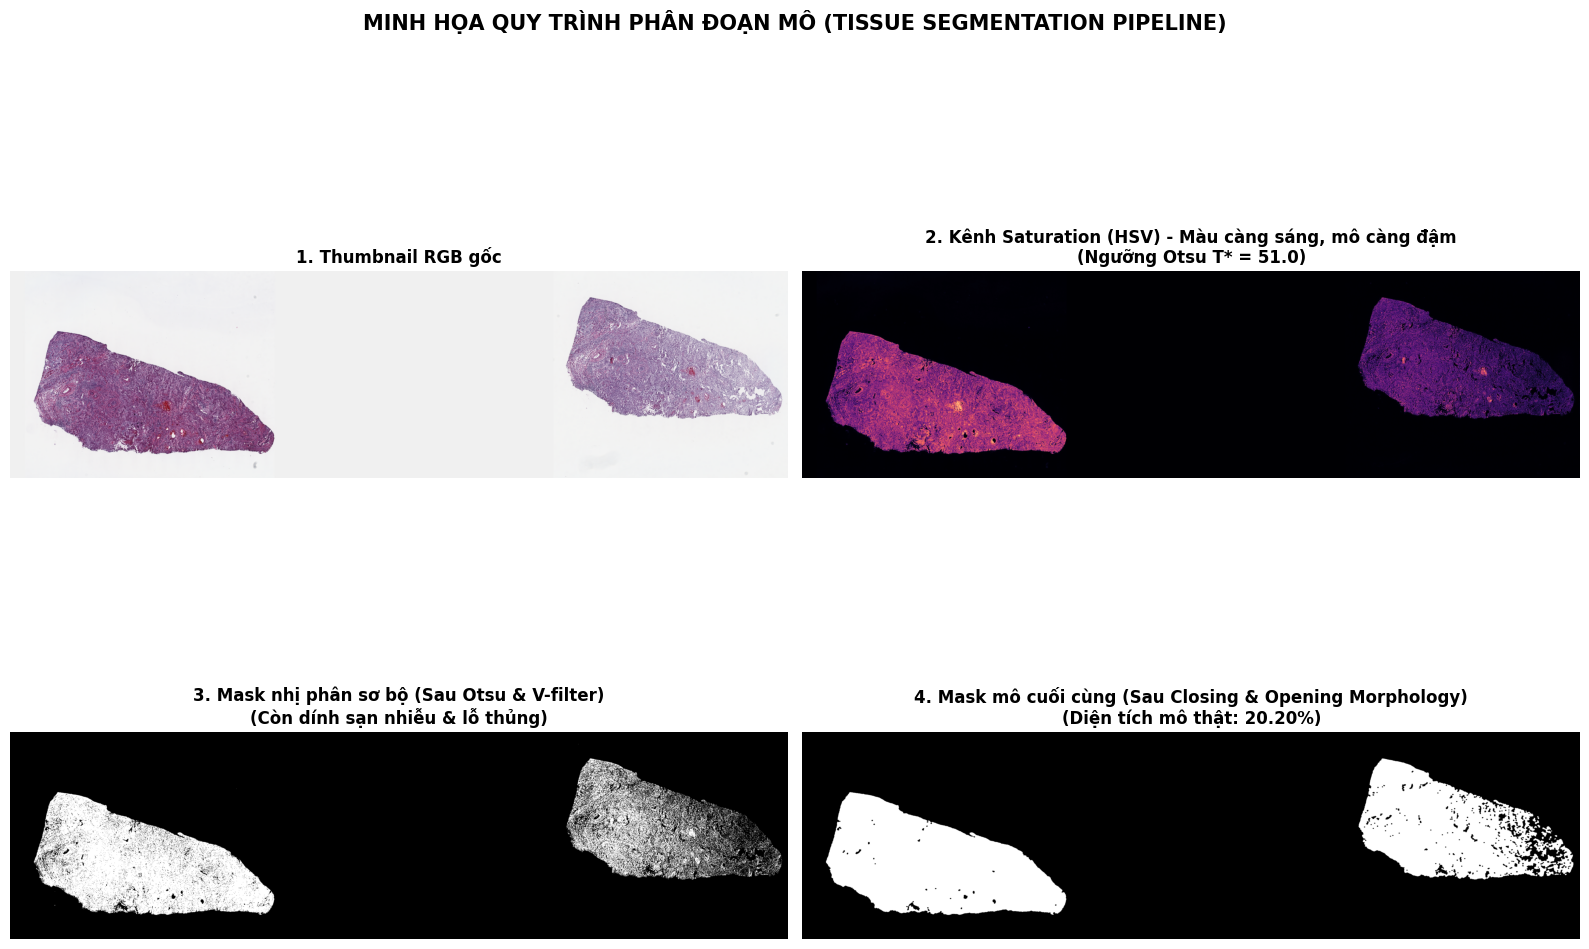

In [33]:
# [CELL 4] MINH HỌA QUY TRÌNH PHÂN ĐOẠN MÔ (TISSUE SEGMENTATION)
# Kỹ thuật sử dụng:
# 1. Color Space Transformation (RGB -> HSV): Cô lập kênh Saturation phản ánh màu nhuộm H&E.
# 2. Otsu's Adaptive Thresholding: Tự động tính ngưỡng phân cực tối đa hóa phương sai giữa 2 lớp mô và nền.
# 3. Value-based Background Clipping: Khử các pixel sáng tuyệt đối (nền kính trong suốt).
# 4. Morphological Closing & Opening (5x5 Elliptical Structuring Element): Lấp lỗ hổng liên bào & xóa bụi kính.

if len(svs_files) > 0:
    slide = openslide.OpenSlide(svs_files[0])
    w_0, h_0 = slide.dimensions
    
    # Bước 1: Lấy Thumbnail ở mức thu nhỏ 32x
    target_w = max(1, int(w_0 / DOWNSAMPLE_MASK))
    target_h = max(1, int(h_0 / DOWNSAMPLE_MASK))
    thumb_rgb = np.array(slide.get_thumbnail((target_w, target_h)).convert("RGB"))
    
    # Bước 2: Chuyển đổi sang HSV và tách các kênh
    thumb_hsv = cv2.cvtColor(thumb_rgb, cv2.COLOR_RGB2HSV)
    h_channel, s_channel, v_channel = cv2.split(thumb_hsv)
    
    # Bước 3: Phân ngưỡng Otsu trên kênh Saturation (S)
    otsu_thresh, raw_mask = cv2.threshold(s_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Bước 4: Lọc nền sáng trong suốt (V > 235)
    raw_mask[v_channel > 235] = 0
    
    # Bước 5: Phép toán hình thái học (Morphological Filter)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)
    clean_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, kernel)
    
    tissue_area_pct = (np.count_nonzero(clean_mask) / clean_mask.size) * 100
    
    print(f"=== KẾT QUẢ TÍNH TOÁN PHÂN ĐOẠN MÔ CHO SLIDE: {os.path.basename(svs_files[0])} ===")
    print(f"  • Ngưỡng Otsu tự động tìm được trên kênh Saturation : T* = {otsu_thresh:.1f} / 255")
    print(f"  • Tổng số pixel trên mask thumbnail                  : {clean_mask.size:,} pixels")
    print(f"  • Số pixel nhận diện là MÔ THỰC                      : {np.count_nonzero(clean_mask):,} pixels ({tissue_area_pct:.2f}%)")
    print(f"  • Số pixel nhận diện là NỀN TRẮNG/KÍNH               : {clean_mask.size - np.count_nonzero(clean_mask):,} pixels ({100 - tissue_area_pct:.2f}%)")
    print("="*70)
    
    # 6. Vẽ biểu đồ đối chứng 4 giai đoạn xử lý
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    axes[0, 0].imshow(thumb_rgb)
    axes[0, 0].set_title("1. Thumbnail RGB gốc", fontsize=12, fontweight="bold")
    axes[0, 0].axis("off")
    
    axes[0, 1].imshow(s_channel, cmap="magma")
    axes[0, 1].set_title(f"2. Kênh Saturation (HSV) - Màu càng sáng, mô càng đậm\n(Ngưỡng Otsu T* = {otsu_thresh:.1f})", fontsize=12, fontweight="bold")
    axes[0, 1].axis("off")
    
    axes[1, 0].imshow(raw_mask, cmap="gray")
    axes[1, 0].set_title("3. Mask nhị phân sơ bộ (Sau Otsu & V-filter)\n(Còn dính sạn nhiễu & lỗ thủng)", fontsize=12, fontweight="bold")
    axes[1, 0].axis("off")
    
    axes[1, 1].imshow(clean_mask, cmap="gray")
    axes[1, 1].set_title(f"4. Mask mô cuối cùng (Sau Closing & Opening Morphology)\n(Diện tích mô thật: {tissue_area_pct:.2f}%)", fontsize=12, fontweight="bold")
    axes[1, 1].axis("off")
    
    plt.suptitle(f"MINH HỌA QUY TRÌNH PHÂN ĐOẠN MÔ (TISSUE SEGMENTATION PIPELINE)", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    slide.close()
else:
    print("[!] Bỏ qua cell vì không có file SVS.")

## 🔬 Cell 5: Trích xuất đặc trưng CPath trên Patch MÔ THỰC (H&E Deconvolution, Blur & Pen Marks)

=== BÁO CÁO ĐẶC TRƯNG ĐO ĐƯỢC TẠI TỌA ĐỘ MÔ (x=85,120, y=16,032) ===
  [1] Điểm sắc nét (Blur Score - Var of Laplacian) : 155.58 (Chuẩn: >= 60.0 -> ĐẠT SẮC NÉT)
  [2] Tỷ lệ vết mực (Pen Mark Ratio)             : 14.49% (Chuẩn: <= 5% -> DÍNH MỰC)
  [3] Mật độ Hematoxylin (Mật độ nhân tế bào)    : 0.2473 OD (Cellularity Index)
  [4] Mật độ Eosin (Chất nền ngoại bào/Bào tương) : 0.0502 OD
  [5] Tỷ số Hematoxylin / Eosin (H/E Ratio)       : 4.9284


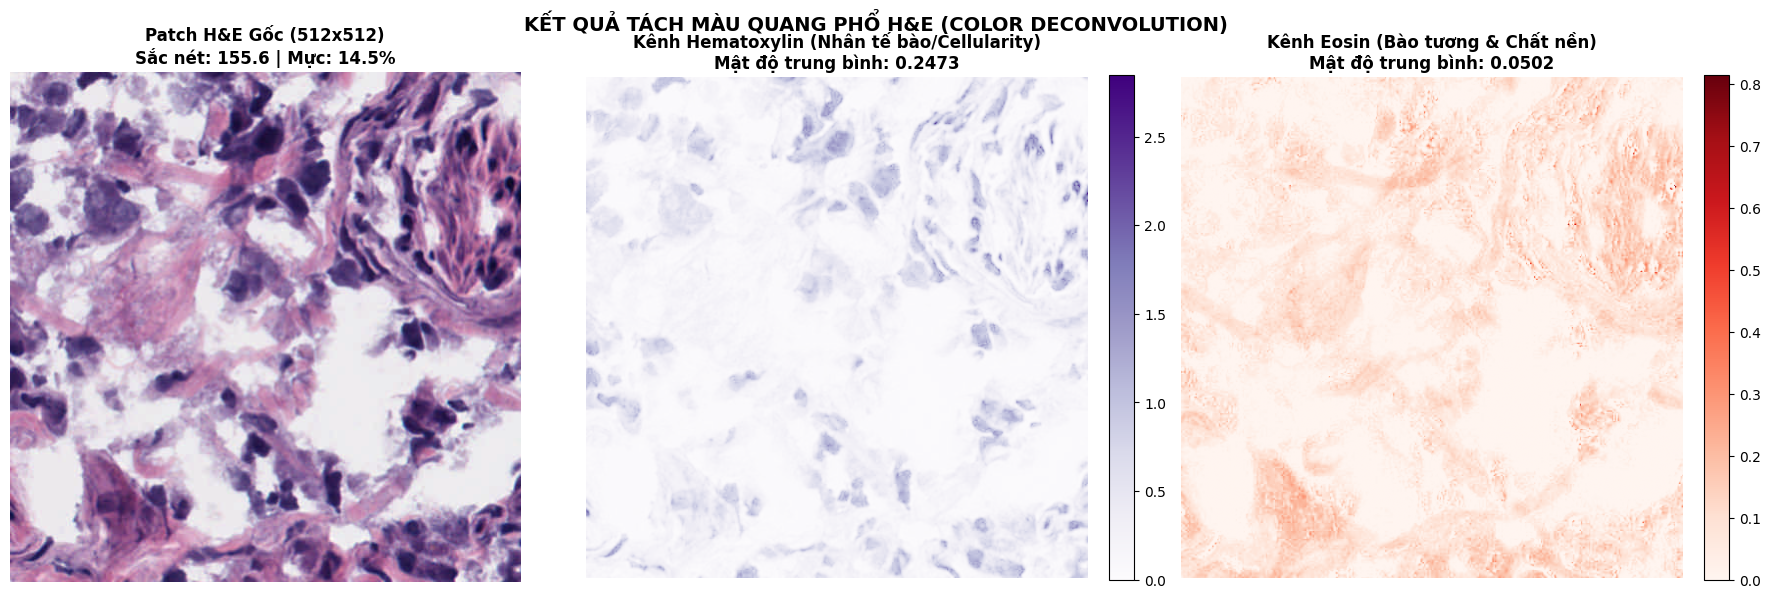

In [34]:
# [CELL 5] KIỂM CHỨNG ĐẶC TRƯNG BỆNH HỌC TRÊN PATCH MÔ THỰC TẾ
# Kỹ thuật sử dụng:
# 1. Tissue-Guided Coordinate Sampling: Dùng mask mô từ Cell 4 để tìm chính xác tọa độ có mô thật (tránh lấy nhầm kính trắng).
# 2. Color Deconvolution (Ruifrok & Johnston Matrix): Chuyển RGB sang Mật độ quang học (OD = -log10(I/255)) để tách nồng độ Hematoxylin (Cellularity) & Eosin.
# 3. Variance of Laplacian: Tích chập ma trận 3x3 Laplace để đo độ sắc nét (Focus Quality).
# 4. Pen Mark Detection: Phát hiện vết mực bút dạ trong dải Hue/Saturation bất biến.

class PathologyFeatureTester:
    @staticmethod
    def compute_all_metrics(patch_rgb):
        # A. Độ sắc nét qua Variance of Laplacian
        gray = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2GRAY)
        blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())
        
        # B. Phát hiện vết mực bút dạ (Pen Mark)
        hsv = cv2.cvtColor(patch_rgb, cv2.COLOR_RGB2HSV)
        h, s, v = cv2.split(hsv)
        ink_mask = ((h >= 35) & (h <= 140) & (s > 100) & (v > 50)) | (((h < 10) | (h > 170)) & (s > 150) & (v > 100))
        ink_ratio = float(np.count_nonzero(ink_mask) / (patch_rgb.shape[0] * patch_rgb.shape[1]))
        
        # C. Tách màu H&E (Optical Density Deconvolution)
        rgb_norm = (patch_rgb.astype(np.float64) + 1.0) / 255.0
        od = -np.log10(rgb_norm)
        deconv_matrix = np.array([
            [0.650, 0.704, 0.286],  # Hematoxylin Vector
            [0.072, 0.990, 0.105],  # Eosin Vector
            [0.268, 0.570, 0.776]   # Background Vector
        ])
        deconv_inv = np.linalg.pinv(deconv_matrix)
        od_flat = od.reshape((-1, 3))
        conc = np.dot(od_flat, deconv_inv)
        conc = np.maximum(0, conc).reshape((patch_rgb.shape[0], patch_rgb.shape[1], 3))
        
        h_density = float(np.mean(conc[:, :, 0]))
        e_density = float(np.mean(conc[:, :, 1]))
        he_ratio = float(h_density / (e_density + 1e-6))
        
        return blur_score, ink_ratio, h_density, e_density, he_ratio, conc[:, :, 0], conc[:, :, 1]

if len(svs_files) > 0:
    slide = openslide.OpenSlide(svs_files[0])
    w_0, h_0 = slide.dimensions
    
    # KỸ THUẬT QUAN TRỌNG: Lấy tọa độ pixel có mô thật từ clean_mask (Cell 4)
    # Tránh lấy tâm (w/2, h/2) vì có thể rơi vào nền kính trắng!
    try:
        y_indices, x_indices = np.where(clean_mask > 0)
        if len(y_indices) > 0:
            mid_idx = len(y_indices) // 2
            sample_x = max(0, min(int(x_indices[mid_idx] * DOWNSAMPLE_MASK), w_0 - PATCH_SIZE))
            sample_y = max(0, min(int(y_indices[mid_idx] * DOWNSAMPLE_MASK), h_0 - PATCH_SIZE))
        else:
            sample_x, sample_y = int(w_0 / 2), int(h_0 / 2)
    except NameError:
        # Fallback nếu chạy riêng Cell 5 mà chưa chạy Cell 4
        sample_x, sample_y = int(w_0 / 2), int(h_0 / 2)
        
    sample_patch = np.array(slide.read_region((sample_x, sample_y), 0, (PATCH_SIZE, PATCH_SIZE)).convert("RGB"))
    slide.close()
    
    blur, ink, h_den, e_den, he_r, h_map, e_map = PathologyFeatureTester.compute_all_metrics(sample_patch)
    
    print(f"=== BÁO CÁO ĐẶC TRƯNG ĐO ĐƯỢC TẠI TỌA ĐỘ MÔ (x={sample_x:,}, y={sample_y:,}) ===")
    print(f"  [1] Điểm sắc nét (Blur Score - Var of Laplacian) : {blur:.2f} (Chuẩn: >= {MIN_BLUR_SCORE} -> {'ĐẠT SẮC NÉT' if blur >= MIN_BLUR_SCORE else 'BỊ MỜ'})")
    print(f"  [2] Tỷ lệ vết mực (Pen Mark Ratio)             : {ink*100:.2f}% (Chuẩn: <= {int(MAX_INK_RATIO*100)}% -> {'SẠCH MỰC' if ink <= MAX_INK_RATIO else 'DÍNH MỰC'})")
    print(f"  [3] Mật độ Hematoxylin (Mật độ nhân tế bào)    : {h_den:.4f} OD (Cellularity Index)")
    print(f"  [4] Mật độ Eosin (Chất nền ngoại bào/Bào tương) : {e_den:.4f} OD")
    print(f"  [5] Tỷ số Hematoxylin / Eosin (H/E Ratio)       : {he_r:.4f}")
    print("="*70)
    
    # Vẽ minh họa tách kênh Hematoxylin & Eosin
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(sample_patch)
    axes[0].set_title(f"Patch H&E Gốc (512x512)\nSắc nét: {blur:.1f} | Mực: {ink*100:.1f}%", fontsize=12, fontweight="bold")
    axes[0].axis("off")
    
    im_h = axes[1].imshow(h_map, cmap="Purples")
    axes[1].set_title(f"Kênh Hematoxylin (Nhân tế bào/Cellularity)\nMật độ trung bình: {h_den:.4f}", fontsize=12, fontweight="bold")
    axes[1].axis("off")
    plt.colorbar(im_h, ax=axes[1], fraction=0.046, pad=0.04)
    
    im_e = axes[2].imshow(e_map, cmap="Reds")
    axes[2].set_title(f"Kênh Eosin (Bào tương & Chất nền)\nMật độ trung bình: {e_den:.4f}", fontsize=12, fontweight="bold")
    axes[2].axis("off")
    plt.colorbar(im_e, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.suptitle("KẾT QUẢ TÁCH MÀU QUANG PHỔ H&E (COLOR DECONVOLUTION)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[!] Bỏ qua cell.")

## ⚡ Cell 6: Chạy Pipeline song song an toàn (ThreadPoolExecutor) & Xuất Manifest

In [35]:
# [CELL 6] TIẾN HÀNH XỬ LÝ HÀNG LOẠT VỚI THREADPOOLEXECUTOR (TƯƠNG THÍCH HOÀN HẢO WINDOWS & LINUX)
# Kỹ thuật sử dụng:
# 1. GIL-Free ThreadPoolExecutor: OpenSlide C-library tự giải phóng GIL trong các hàm đọc I/O,
#    giúp chạy đa luồng cực nhanh mà KHÔNG bị lỗi BrokenProcessPool trên Windows Jupyter Notebook!
# 2. Virtual Grid Tiling: Quét lưới tọa độ ảo trên Level 0.
# 3. Coordinate Mapping: Ánh xạ tọa độ ô vuông sang mask thumbnail để kiểm tra tỷ lệ mô >= 50%.
# 4. Smart Resume Check: Tự động bỏ qua patch đã lưu nếu chạy lại.

import time
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from PIL import Image

def process_single_slide_cpath(svs_path):
    slide_name = os.path.splitext(os.path.basename(svs_path))[0]
    slide_out_dir = os.path.join(OUTPUT_DIR, slide_name)
    os.makedirs(slide_out_dir, exist_ok=True)
    
    try:
        slide = openslide.OpenSlide(svs_path)
    except Exception as e:
        return slide_name, [], f"Lỗi mở file: {e}"

    w_0, h_0 = slide.dimensions
    app_mag = get_slide_mag(slide)
    scale = app_mag / TARGET_MAG if app_mag >= TARGET_MAG else 1.0
    step_size = int(PATCH_SIZE * scale)
    
    # Tạo Mask phân đoạn
    target_w = max(1, int(w_0 / DOWNSAMPLE_MASK))
    target_h = max(1, int(h_0 / DOWNSAMPLE_MASK))
    thumb_rgb = np.array(slide.get_thumbnail((target_w, target_h)).convert("RGB"))
    thumb_hsv = cv2.cvtColor(thumb_rgb, cv2.COLOR_RGB2HSV)
    _, s_ch, v_ch = cv2.split(thumb_hsv)
    _, raw_m = cv2.threshold(s_ch, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    raw_m[v_ch > 235] = 0
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    tissue_mask = cv2.morphologyEx(cv2.morphologyEx(raw_m, cv2.MORPH_CLOSE, kernel), cv2.MORPH_OPEN, kernel)
    
    slide_records = []
    saved_patches = 0
    total_grid_scanned = 0
    
    # Duyệt lưới tọa độ ảo
    for y in range(0, h_0 - step_size + 1, step_size):
        for x in range(0, w_0 - step_size + 1, step_size):
            total_grid_scanned += 1
            
            # Ánh xạ tọa độ Level 0 sang mask
            mx1, my1 = int(x / DOWNSAMPLE_MASK), int(y / DOWNSAMPLE_MASK)
            mx2, my2 = int((x + step_size) / DOWNSAMPLE_MASK), int((y + step_size) / DOWNSAMPLE_MASK)
            
            m_crop = tissue_mask[my1:my2, mx1:mx2]
            if m_crop.size == 0:
                continue
                
            tissue_ratio = float(np.count_nonzero(m_crop) / m_crop.size)
            
            rec = {
                "slide_id": slide_name,
                "patch_filename": f"{slide_name}_{x}_{y}.jpg",
                "coord_x": x,
                "coord_y": y,
                "tissue_ratio": round(tissue_ratio, 4),
                "blurriness": 0.0,
                "ink_ratio": 0.0,
                "hematoxylin_density": 0.0,
                "eosin_density": 0.0,
                "he_ratio": 0.0,
                "is_kept": False,
                "rejection_reason": "Low Tissue (Nền kính)"
            }
            
            # Chỉ đọc ảnh thật từ SVS khi đạt ngưỡng mô
            if tissue_ratio >= TISSUE_THRESHOLD:
                patch_img = slide.read_region((x, y), 0, (step_size, step_size)).convert("RGB")
                if step_size != PATCH_SIZE:
                    try:
                        patch_img = patch_img.resize((PATCH_SIZE, PATCH_SIZE), Image.Resampling.BILINEAR)
                    except AttributeError:
                        patch_img = patch_img.resize((PATCH_SIZE, PATCH_SIZE), Image.BILINEAR)
                    
                patch_np = np.array(patch_img)
                blur, ink, h_den, e_den, he_r, _, _ = PathologyFeatureTester.compute_all_metrics(patch_np)
                
                rec["blurriness"] = round(blur, 2)
                rec["ink_ratio"] = round(ink, 4)
                rec["hematoxylin_density"] = round(h_den, 4)
                rec["eosin_density"] = round(e_den, 4)
                rec["he_ratio"] = round(he_r, 4)
                
                if blur < MIN_BLUR_SCORE:
                    rec["rejection_reason"] = "Blurry / Out of Focus"
                elif ink > MAX_INK_RATIO:
                    rec["rejection_reason"] = "Pen Mark Artifact"
                else:
                    rec["is_kept"] = True
                    rec["rejection_reason"] = "Passed QC (Đạt chuẩn)"
                    
                    patch_path = os.path.join(slide_out_dir, rec["patch_filename"])
                    # Nếu patch chưa tồn tại thì lưu (tránh ghi đè nếu chạy lại)
                    if not os.path.exists(patch_path):
                        patch_img.save(patch_path, "JPEG", quality=JPEG_QUALITY)
                    saved_patches += 1
                    
            slide_records.append(rec)
            
    slide.close()
    return slide_name, slide_records, f"{saved_patches}/{total_grid_scanned} patches"

# Chạy tiến trình xử lý đa luồng
if len(svs_files) > 0:
    print(f"[🚀] BẮT ĐẦU XỬ LÝ SONG SONG {len(svs_files)} SLIDES...")
    start_t = time.time()
    all_records = []
    
    # Sử dụng ThreadPoolExecutor tương thích 100% cả Windows & Linux
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        results = list(tqdm(executor.map(process_single_slide_cpath, svs_files), total=len(svs_files), desc="Processing WSI"))
        
    for s_name, recs, log_msg in results:
        all_records.extend(recs)
        kept_cnt = sum(1 for r in recs if r.get('is_kept'))
        total_cnt = len(recs)
        print(f"  [✓] {s_name:<30}: Lưu {kept_cnt:>5,} / {total_cnt:>5,} ô (Đã lọc bỏ {(1 - kept_cnt/max(1, total_cnt))*100:>5.1f}% nền)")
        
    manifest_df = pd.DataFrame(all_records)
    manifest_path = os.path.join(OUTPUT_DIR, "patches_manifest.csv")
    manifest_df.to_csv(manifest_path, index=False)
    
    elapsed_min = (time.time() - start_t) / 60.0
    print("\n" + "="*75)
    print(f"[✓] HOÀN TẤT TOÀN BỘ PIPELINE TRONG {elapsed_min:.2f} PHÚT!")
    print(f"  • Bảng Metadata đã xuất      : {manifest_path}")
    print(f"  • Tổng số ô đã quét         : {len(manifest_df):,}")
    print(f"  • Tổng số patch sạch đã lưu : {manifest_df['is_kept'].sum():,} ({manifest_df['is_kept'].mean()*100:.2f}%)")
    print(f"  • Tỷ lệ loại bỏ nền/nhiễu    : {(1 - manifest_df['is_kept'].mean())*100:.2f}%")
    print("="*75)
else:
    print("[!] Không có file SVS để xử lý.")

[🚀] BẮT ĐẦU XỬ LÝ SONG SONG 172 SLIDES...


Processing WSI: 100%|██████████| 172/172 [41:47<00:00, 14.58s/it] 


  [✓] TCGA-4P-AA8J                  : Lưu     8 / 2,781 ô (Đã lọc bỏ  99.7% nền)
  [✓] TCGA-BA-4074                  : Lưu   334 /   620 ô (Đã lọc bỏ  46.1% nền)
  [✓] TCGA-BA-4077                  : Lưu   219 / 1,120 ô (Đã lọc bỏ  80.4% nền)
  [✓] TCGA-BA-5153                  : Lưu   331 /   713 ô (Đã lọc bỏ  53.6% nền)
  [✓] TCGA-BA-5556                  : Lưu    95 /   667 ô (Đã lọc bỏ  85.8% nền)
  [✓] TCGA-BA-5557                  : Lưu   161 /   418 ô (Đã lọc bỏ  61.5% nền)
  [✓] TCGA-BA-6872                  : Lưu   337 /   638 ô (Đã lọc bỏ  47.2% nền)
  [✓] TCGA-BA-6873                  : Lưu    93 /   340 ô (Đã lọc bỏ  72.6% nền)
  [✓] TCGA-BA-7269                  : Lưu   342 / 1,302 ô (Đã lọc bỏ  73.7% nền)
  [✓] TCGA-BA-A6D8                  : Lưu     9 / 1,610 ô (Đã lọc bỏ  99.4% nền)
  [✓] TCGA-BA-A6DG                  : Lưu    37 / 2,184 ô (Đã lọc bỏ  98.3% nền)
  [✓] TCGA-BA-A6DJ                  : Lưu   139 / 2,079 ô (Đã lọc bỏ  93.3% nền)
  [✓] TCGA-BB-4224          

## 📊 Cell 7: Bảng điều khiển phân tích đặc trưng & Thống kê sinh học (Profiling Dashboard)

C:\Users\trita\AppData\Local\Temp\ipykernel_29800\1724987586.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=kept_df[kept_df["slide_id"].isin(top_slides)], x="slide_id", y="hematoxylin_density", palette="Set2", ax=ax5)
C:\Users\trita\AppData\Local\Temp\ipykernel_29800\1724987586.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(ax5.get_xticklabels(), rotation=30, ha="right", fontsize=8)


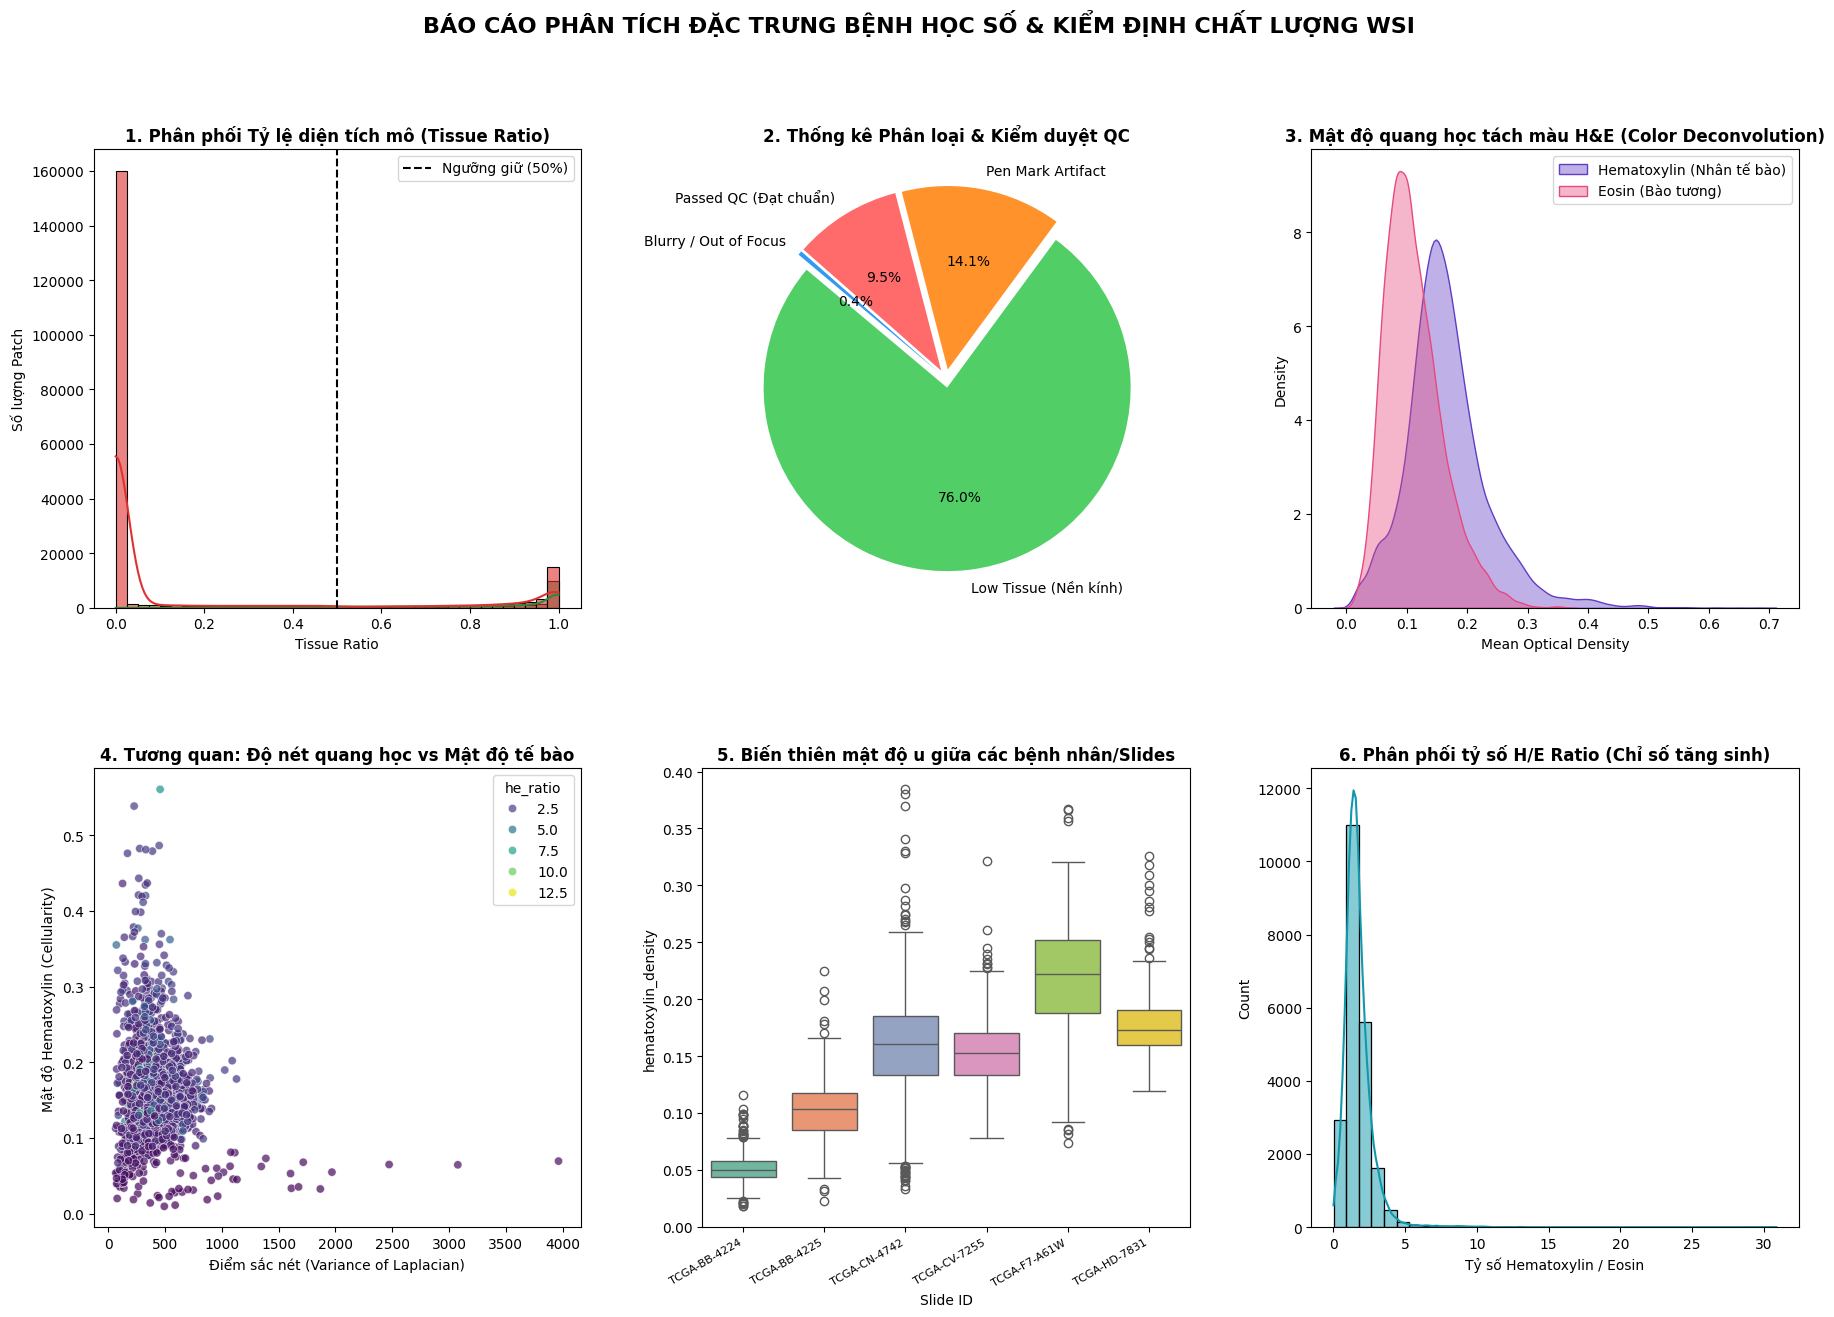

In [36]:
# [CELL 7] TRỰC QUAN HÓA TOÀN DIỆN ĐẶC TRƯNG MÔ HỌC & KIỂM ĐỊNH CHẤT LƯỢNG
# Kỹ thuật hiển thị:
# 1. Histogram & Kernel Density Estimation (KDE) của diện tích mô.
# 2. Pie Chart phân rã tỷ lệ từ chối theo nguyên nhân (QC Breakdown).
# 3. Optical Density Distribution của Hematoxylin & Eosin.
# 4. Biplot Scatter: Tương quan giữa độ sắc nét quang học và mật độ tế bào.
# 5. Inter-patient Boxplot: Đo lường độ biến thiên mật độ u giữa các bệnh nhân.
# 6. H/E Ratio Distribution: Đo chỉ số tăng sinh tế bào.

import seaborn as sns

manifest_path = os.path.join(OUTPUT_DIR, "patches_manifest.csv")
if os.path.exists(manifest_path):
    df = pd.read_csv(manifest_path)
    kept_df = df[df["is_kept"] == True]
    
    fig = plt.figure(figsize=(22, 14))
    gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25)
    
    # 1. Phân phối diện tích mô (Kept vs Discarded)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.histplot(data=df, x="tissue_ratio", hue="is_kept", bins=40, kde=True, 
                 palette={True: "#2b8a3e", False: "#e03131"}, ax=ax1, alpha=0.6)
    ax1.axvline(TISSUE_THRESHOLD, color="black", linestyle="--", label=f"Ngưỡng giữ ({int(TISSUE_THRESHOLD*100)}%)")
    ax1.set_title("1. Phân phối Tỷ lệ diện tích mô (Tissue Ratio)", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Tissue Ratio")
    ax1.set_ylabel("Số lượng Patch")
    ax1.legend()
    
    # 2. Biểu đồ tròn lý do từ chối QC
    ax2 = fig.add_subplot(gs[0, 1])
    reasons = df["rejection_reason"].value_counts()
    colors = ["#51cf66", "#ff922b", "#ff6b6b", "#339af0"]
    ax2.pie(reasons.values, labels=reasons.index, autopct='%1.1f%%', startangle=140,
            colors=colors[:len(reasons)], explode=[0.05]*len(reasons))
    ax2.set_title("2. Thống kê Phân loại & Kiểm duyệt QC", fontsize=12, fontweight="bold")
    
    # 3. Phổ mật độ quang học H&E
    ax3 = fig.add_subplot(gs[0, 2])
    if not kept_df.empty:
        sns.kdeplot(kept_df["hematoxylin_density"], label="Hematoxylin (Nhân tế bào)", color="#5f3dc4", fill=True, alpha=0.4, ax=ax3)
        sns.kdeplot(kept_df["eosin_density"], label="Eosin (Bào tương)", color="#e64980", fill=True, alpha=0.4, ax=ax3)
        ax3.set_title("3. Mật độ quang học tách màu H&E (Color Deconvolution)", fontsize=12, fontweight="bold")
        ax3.set_xlabel("Mean Optical Density")
        ax3.legend()
        
    # 4. Tương quan Độ sắc nét vs Mật độ tế bào
    ax4 = fig.add_subplot(gs[1, 0])
    if not kept_df.empty:
        sample_pts = kept_df.sample(min(1500, len(kept_df)), random_state=42)
        sns.scatterplot(data=sample_pts, x="blurriness", y="hematoxylin_density", hue="he_ratio", palette="viridis", alpha=0.7, ax=ax4)
        ax4.set_title("4. Tương quan: Độ nét quang học vs Mật độ tế bào", fontsize=12, fontweight="bold")
        ax4.set_xlabel("Điểm sắc nét (Variance of Laplacian)")
        ax4.set_ylabel("Mật độ Hematoxylin (Cellularity)")
        
    # 5. So sánh mật độ nhân tế bào giữa các bệnh nhân
    ax5 = fig.add_subplot(gs[1, 1])
    if not kept_df.empty:
        top_slides = kept_df["slide_id"].value_counts().head(6).index
        sns.boxplot(data=kept_df[kept_df["slide_id"].isin(top_slides)], x="slide_id", y="hematoxylin_density", palette="Set2", ax=ax5)
        ax5.set_title("5. Biến thiên mật độ u giữa các bệnh nhân/Slides", fontsize=12, fontweight="bold")
        ax5.set_xticklabels(ax5.get_xticklabels(), rotation=30, ha="right", fontsize=8)
        ax5.set_xlabel("Slide ID")
        
    # 6. Phân phối H/E Ratio
    ax6 = fig.add_subplot(gs[1, 2])
    if not kept_df.empty:
        sns.histplot(kept_df["he_ratio"], bins=35, color="#1098ad", kde=True, ax=ax6)
        ax6.set_title("6. Phân phối tỷ số H/E Ratio (Chỉ số tăng sinh)", fontsize=12, fontweight="bold")
        ax6.set_xlabel("Tỷ số Hematoxylin / Eosin")
        
    plt.suptitle("BÁO CÁO PHÂN TÍCH ĐẶC TRƯNG BỆNH HỌC SỐ & KIỂM ĐỊNH CHẤT LƯỢNG WSI", fontsize=16, fontweight="bold", y=0.98)
    plt.show()
else:
    print("[!] Chưa tìm thấy file manifest CSV.")

## 🗺️ Cell 8: Tái tạo bản đồ không gian toàn tiêu bản (Spatial WSI Heatmaps)

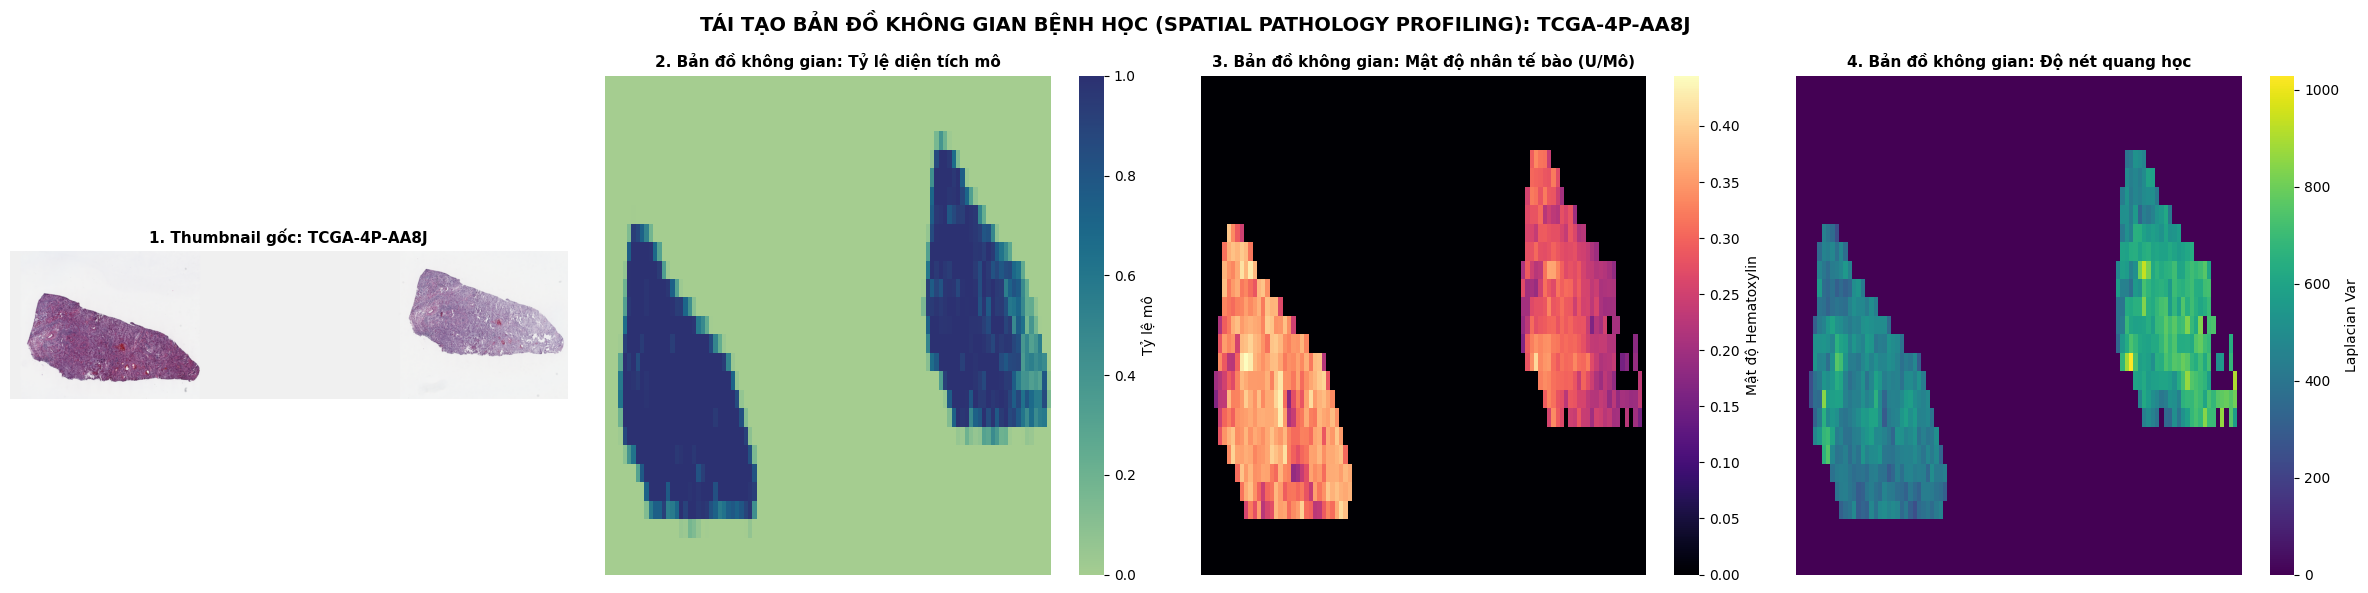

In [37]:
# [CELL 8] TÁI TẠO BẢN ĐỒ KHÔNG GIAN TOÀN DIỆN (SPATIAL HEATMAPS)
# Kỹ thuật: 2D Spatial Coordinate Mapping & Continuous Feature Heatmap Interpolation

if os.path.exists(manifest_path) and len(svs_files) > 0:
    sample_svs = svs_files[0]
    s_name = os.path.splitext(os.path.basename(sample_svs))[0]
    
    slide = openslide.OpenSlide(sample_svs)
    thumb = slide.get_thumbnail((1024, 1024)).convert("RGB")
    slide.close()
    
    df_s = pd.read_csv(manifest_path)
    df_s = df_s[df_s["slide_id"] == s_name]
    
    if not df_s.empty:
        xs = sorted(df_s["coord_x"].unique())
        ys = sorted(df_s["coord_y"].unique())
        x_map = {v: i for i, v in enumerate(xs)}
        y_map = {v: i for i, v in enumerate(ys)}
        
        g_tissue = np.zeros((len(ys), len(xs)))
        g_cell = np.zeros((len(ys), len(xs)))
        g_blur = np.zeros((len(ys), len(xs)))
        
        for _, r in df_s.iterrows():
            iy, ix = y_map[r["coord_y"]], x_map[r["coord_x"]]
            g_tissue[iy, ix] = r["tissue_ratio"]
            g_cell[iy, ix] = r["hematoxylin_density"]
            g_blur[iy, ix] = r["blurriness"]
            
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        
        axes[0].imshow(thumb)
        axes[0].set_title(f"1. Thumbnail gốc: {s_name}", fontsize=11, fontweight="bold")
        axes[0].axis("off")
        
        sns.heatmap(g_tissue, cmap="crest", ax=axes[1], cbar_kws={'label': 'Tỷ lệ mô'})
        axes[1].set_title("2. Bản đồ không gian: Tỷ lệ diện tích mô", fontsize=11, fontweight="bold")
        axes[1].axis("off")
        
        sns.heatmap(g_cell, cmap="magma", ax=axes[2], cbar_kws={'label': 'Mật độ Hematoxylin'})
        axes[2].set_title("3. Bản đồ không gian: Mật độ nhân tế bào (U/Mô)", fontsize=11, fontweight="bold")
        axes[2].axis("off")
        
        sns.heatmap(g_blur, cmap="viridis", ax=axes[3], cbar_kws={'label': 'Laplacian Var'})
        axes[3].set_title("4. Bản đồ không gian: Độ nét quang học", fontsize=11, fontweight="bold")
        axes[3].axis("off")
        
        plt.suptitle(f"TÁI TẠO BẢN ĐỒ KHÔNG GIAN BỆNH HỌC (SPATIAL PATHOLOGY PROFILING): {s_name}", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    print("[!] Chưa có dữ liệu.")

## 📦 Cell 9: Đóng gói và Nén dữ liệu đầu ra TRỰC TIẾP TRONG DỰ ÁN

In [38]:
# [CELL 9] ĐÓNG GÓI THÀNH FILE ZIP TRỰC TIẾP TRONG THƯ MỤC DỰ ÁN
# Kỹ thuật: Fast Streamlined ZIP Archiving

import zipfile

zip_out = os.path.join(PROJECT_ROOT, "tcga_brca_filtered_patches.zip")
print(f"[+] Đang tiến hành đóng gói thư mục: {OUTPUT_DIR} -> {zip_out}...")

patch_files = glob.glob(os.path.join(OUTPUT_DIR, "**", "*.jpg"), recursive=True)
manifest_file = os.path.join(OUTPUT_DIR, "patches_manifest.csv")

with zipfile.ZipFile(zip_out, 'w', zipfile.ZIP_DEFLATED) as zf:
    if os.path.exists(manifest_file):
        zf.write(manifest_file, arcname="patches_manifest.csv")
        
    for pf in tqdm(patch_files, desc="Zipping Patches"):
        arc_name = os.path.relpath(pf, OUTPUT_DIR)
        zf.write(pf, arcname=os.path.join("processed_patches", arc_name))

zip_size_mb = os.path.getsize(zip_out) / (1024 * 1024)
print("\n" + "="*60)
print(f"[✓] ĐÃ TẠO FILE ZIP THÀNH CÔNG TẠI THƯ MỤC DỰ ÁN!")
print(f"  • Đường dẫn file zip : {zip_out}")
print(f"  • Dung lượng file zip: {zip_size_mb:.2f} MB")
print(f"  • Tổng số patch trong zip: {len(patch_files):,} ảnh")
print("="*60)

[+] Đang tiến hành đóng gói thư mục: d:\nb-w-output\processed_patches -> d:\nb-w-output\tcga_brca_filtered_patches.zip...


Zipping Patches: 100%|██████████| 21970/21970 [09:10<00:00, 39.90it/s]



[✓] ĐÃ TẠO FILE ZIP THÀNH CÔNG TẠI THƯ MỤC DỰ ÁN!
  • Đường dẫn file zip : d:\nb-w-output\tcga_brca_filtered_patches.zip
  • Dung lượng file zip: 1467.29 MB
  • Tổng số patch trong zip: 21,970 ảnh
